# Assignment 11.1: What Drives the Price of a Car? <a id = 'top'></a>

**Each phase of the process:**
1. [Business Understanding](#business-understanding)
2. [Data Understanding](#data-understanding)
3. [Data Preparation](#data-preparation)
4. [Modeling](#modeling)
5. [Evaluation](#evaluation)
6. [Deployment](#deployment)

## 1. Business Understanding <a id = "business-understanding"></a>

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Business Problem
The client is a used car dealership. The assignment states the goal is to
understand what factors make a used car more or less expensive, so the
dealership can learn what consumers value in a used car.

### Business Objective
Analyze the dataset to identify which factors are associated with used car
prices, and provide clear, actionable recommendations to the dealership
about what consumers value.

### Data Science Problem
This is a regression problem: price is a continuous target variable, and the
task is to determine which features in the dataset are associated with it
and how.

### Success Criteria
- Clear identification of key drivers of used car price
- A final report translating technical findings into concrete, non-technical
  recommendations for inventory decisions

[Back to Top](#top)

## 2. Data Understanding <a id = "data-understanding"></a>

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Overview
- Source: Kaggle used car dataset (subset of ~426K rows sampled from an
  original 3M-row dataset)
- Format: single CSV file

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
data = pd.read_csv("data/vehicles.csv")

print(data.head())

           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az  
1  NaN  NaN         NaN    ar  
2 

### Data Description

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [4]:
data.describe().round(2)

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.00,422480.00
mean,7.311487e+09,7.519903e+04,2011.24,98043.33
std,4.473170e+06,1.218228e+07,9.45,213881.50
min,7.207408e+09,0.000000e+00,1900.00,0.00
25%,7.308143e+09,5.900000e+03,2008.00,37704.00
50%,7.312621e+09,1.395000e+04,2013.00,85548.00
75%,7.315254e+09,2.648575e+04,2017.00,133542.50
max,7.317101e+09,3.736929e+09,2022.00,10000000.00


### Data Quality

In [5]:
# Check for missing values
data.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [ ]:
# From data.describe(), 'price' and 'odometer' have some extreme values. Trimming the dataset to remove outliers, keeping positive values up to 99% quantile range.
price_high = data['price'].quantile(0.99)
odometer_high = data['odometer'].quantile(0.99)
data = data[(data['price'] >0) & (data['price'] <= price_high) & (data['odometer'] > 0) & (data['odometer'] <= odometer_high)]

data.describe().round(2)

,id,price,year,odometer
count,3.825280e+05,382528.00,381539.00,382528.00
mean,7.311479e+09,18263.36,2011.09,91651.29
std,4.387254e+06,13424.40,9.41,60777.02
min,7.301583e+09,1.00,1900.00,1.00
25%,7.308097e+09,7078.50,2008.00,39000.00
50%,7.312603e+09,15000.00,2013.00,87179.50
75%,7.315246e+09,26998.00,2017.00,134449.00
max,7.317101e+09,66995.00,2022.00,280000.00


In [55]:
data.info()

<class 'pandas.DataFrame'>
Index: 382528 entries, 27 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            382528 non-null  int64  
 1   region        382528 non-null  str    
 2   price         382528 non-null  int64  
 3   year          381539 non-null  float64
 4   manufacturer  368018 non-null  str    
 5   model         378292 non-null  str    
 6   condition     236596 non-null  str    
 7   cylinders     227292 non-null  str    
 8   fuel          380268 non-null  str    
 9   odometer      382528 non-null  float64
 10  title_status  375430 non-null  str    
 11  transmission  381043 non-null  str    
 12  VIN           235887 non-null  str    
 13  drive         265698 non-null  str    
 14  size          108171 non-null  str    
 15  type          299866 non-null  str    
 16  paint_color   269633 non-null  str    
 17  state         382528 non-null  str    
dtypes: float64(2), int6

[Back to Top](#top)

## 3. Data Preparation <a id = "data-preparation"></a>

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [56]:
# Define column groups per data type
numeric_columns = data.drop(columns = ['id']).select_dtypes(include=['int', 'float']).columns # dropping id which doesn't have analytical value
numeric_features = numeric_columns.drop('price') # dropping price which is the target variable
categorical_columns = data.select_dtypes(include=['str']).columns
categorical_features = categorical_columns.drop('VIN') # dropping VIN which doesn't have analytical value

print("Numeric columns:", numeric_columns)
print("Numeric features:", numeric_features)
print("Categorical columns:", categorical_columns)
print("Categorical features:", categorical_features)

Numeric columns: Index(['price', 'year', 'odometer'], dtype='str')
Numeric features: Index(['year', 'odometer'], dtype='str')
Categorical columns: Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'state'],
      dtype='str')
Categorical features: Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color',
       'state'],
      dtype='str')


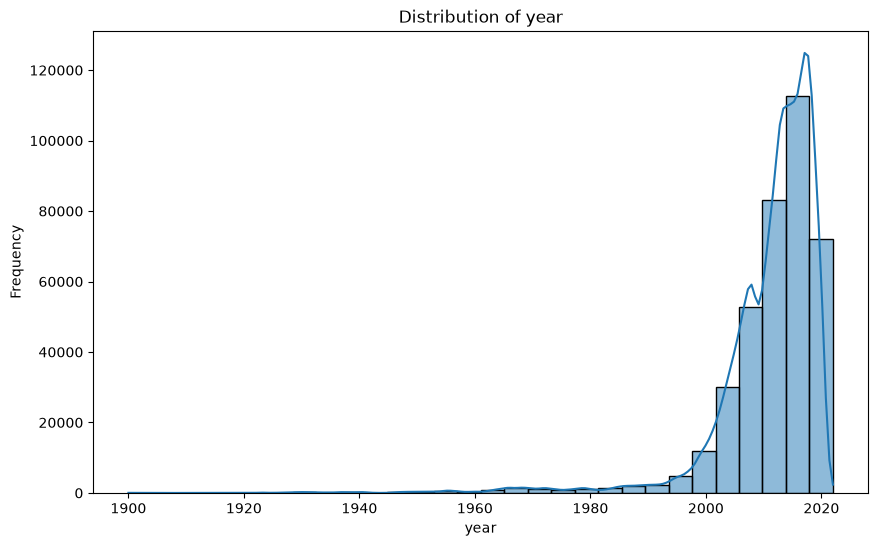

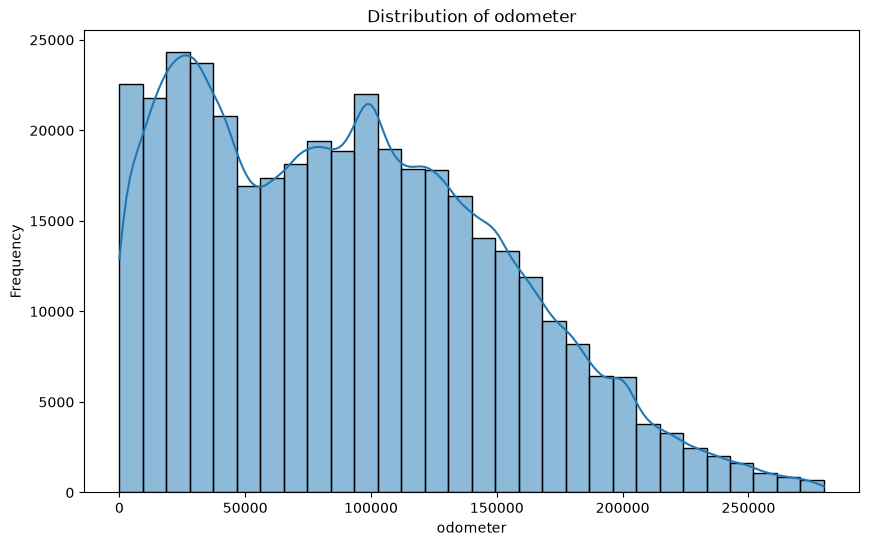

In [57]:
# plot dristribution of numeric features
for col in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [112]:
# value counts for categorical features to check which features potentially have analytical value
for col in categorical_features:
    print("--------------------------------")
    print("--------------------------------")
    print(f"Value counts for {col}:")
    print(data[col].value_counts())

--------------------------------
--------------------------------
Value counts for manufacturer:
manufacturer
ford               62427
chevrolet          48766
toyota             30863
honda              19545
nissan             17215
jeep               17209
ram                15803
gmc                14763
bmw                13580
dodge              12076
mercedes-benz      10012
hyundai             9272
subaru              8914
volkswagen          8782
lexus               7635
kia                 7515
audi                7072
cadillac            6364
acura               5652
chrysler            5584
buick               5117
mazda               4982
infiniti            4447
lincoln             3963
volvo               3120
mitsubishi          3090
mini                2245
pontiac             2195
jaguar              1892
rover               1886
porsche             1190
mercury             1125
saturn              1065
alfa-romeo           842
tesla                808
fiat           

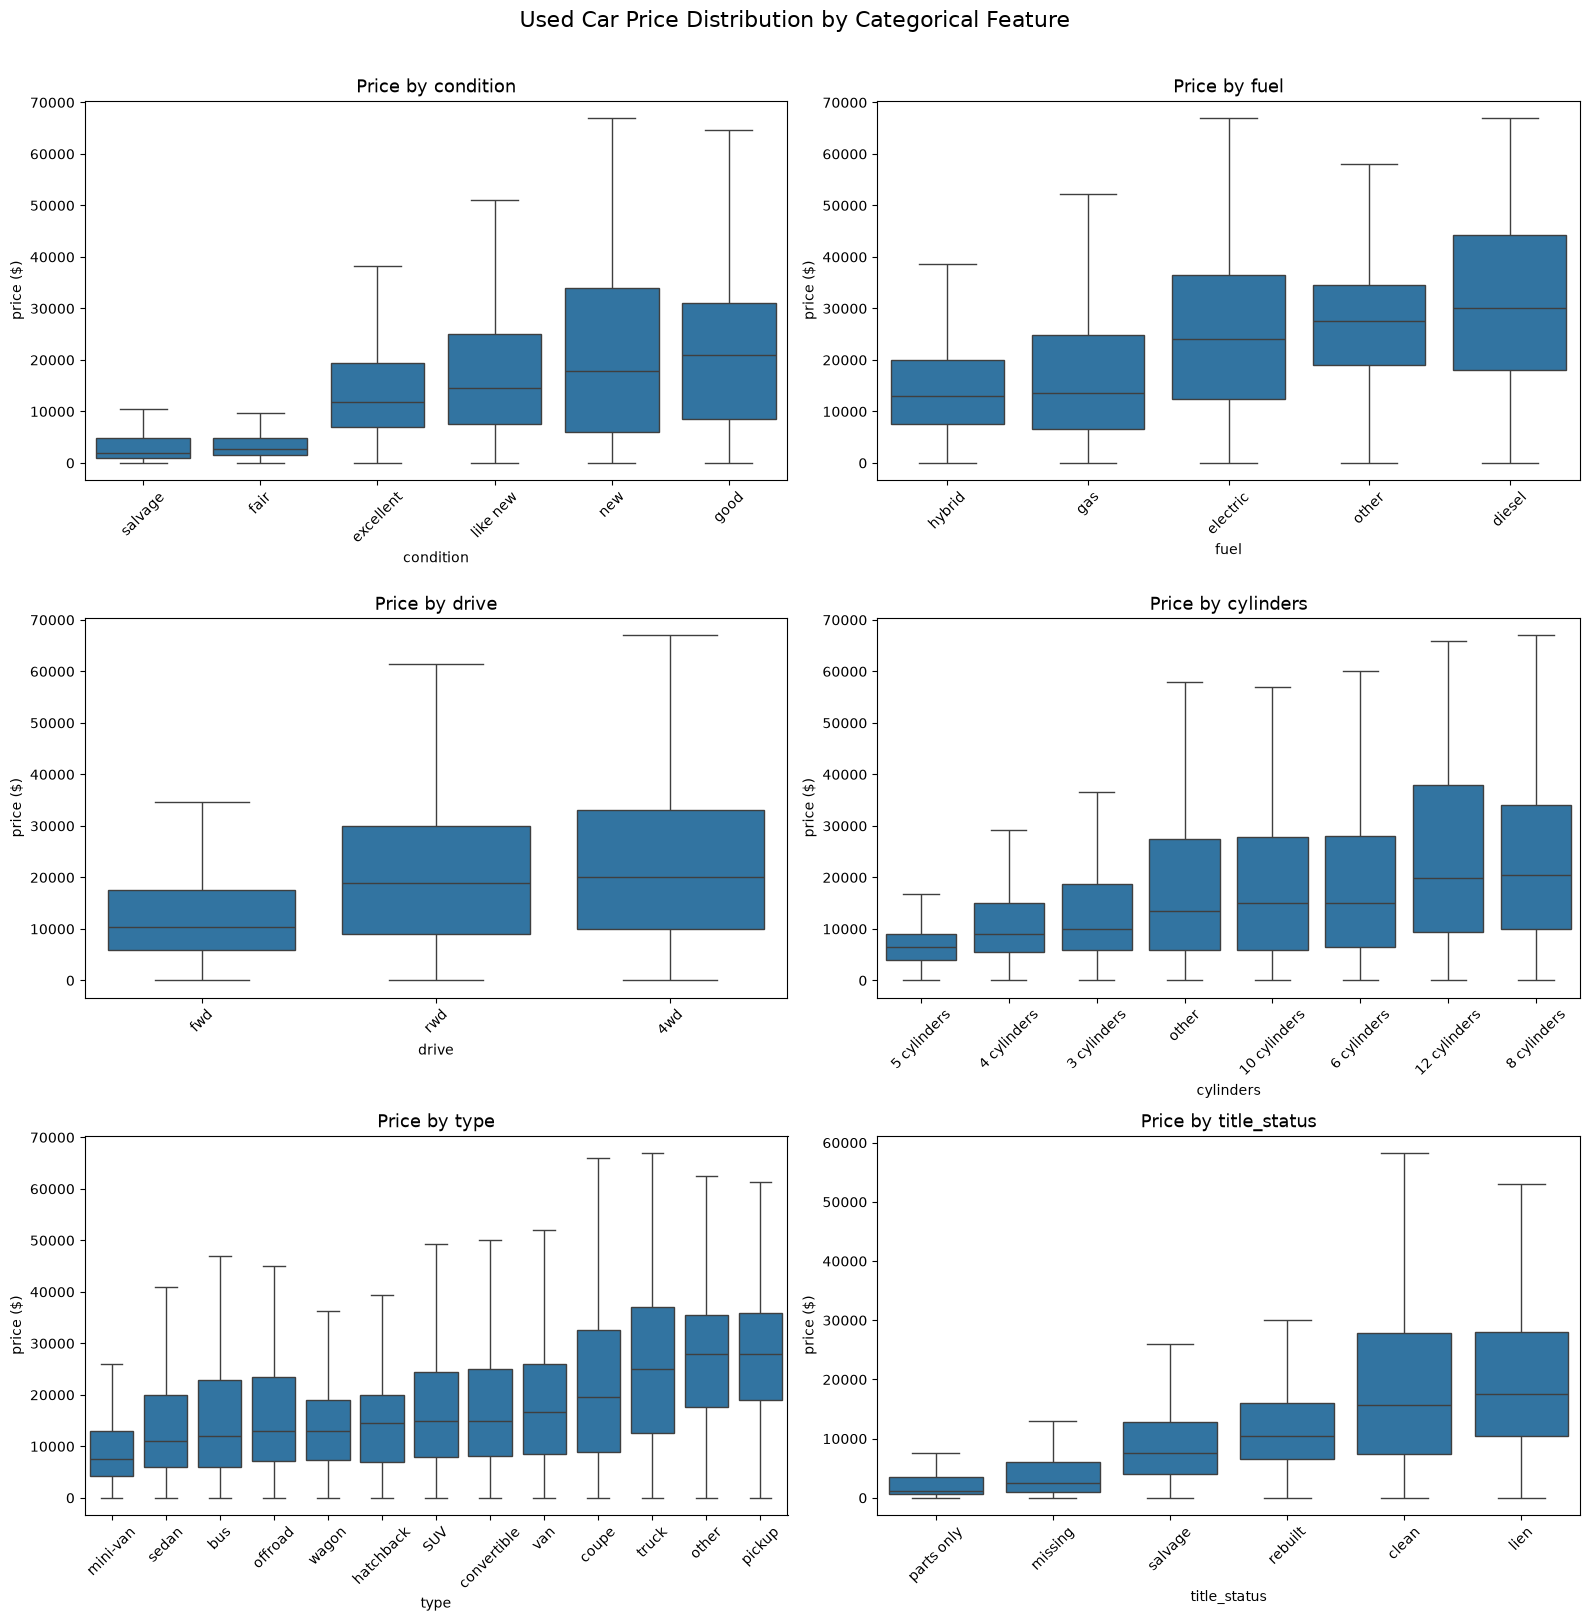

In [146]:
# Categorical EDA: how price distributes across key categorical features
import os
os.makedirs('images', exist_ok=True)

cat_plot_cols = ['condition', 'fuel', 'drive', 'cylinders', 'type', 'title_status']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_plot_cols):
    order = data.groupby(col)['price'].median().sort_values().index  # order by median price
    sns.boxplot(data=data, x=col, y='price', order=order, ax=ax, showfliers=False)
    ax.set_title(f'Price by {col}', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('price ($)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Used Car Price Distribution by Categorical Feature', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('images/categorical_price_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
categorical_features = categorical_features.drop(['region', 'model']) # dropping features which has too many unique values to be useful
data[categorical_features].isna().sum() # check for missing values in the remaining categorical features

manufacturer     14510
condition       145932
cylinders       155236
fuel              2260
title_status      7098
transmission      1485
drive           116830
size            274357
type             82662
paint_color     112895
state                0
dtype: int64

In [60]:
#vehicles = data.drop(columns = ['id', 'VIN', 'region', 'manufacturer', 'model', 'state']) # drop fields which are not useful for analysis
vehicles = data[categorical_features.tolist() + numeric_features.tolist() + ['price']] # keep only the features which are useful for analysis
vehicles = vehicles.drop("size", axis=1) # drop size which has too many missing values to be useful for analysis

vehicles['cylinders_numeric'] = vehicles['cylinders'].str.extract('(\d+)').astype(float) # convert cylinders to numeric
vehicles['cylinders_numeric'] = vehicles['cylinders_numeric'].fillna(vehicles['cylinders_numeric'].median()) # fill missing values with median

vehicles['condition_numeric'] = vehicles['condition'].map({'new': 5, 'like new': 4, 'excellent': 3, 'good': 2, 'fair': 1, 'salvage': 0}) # convert condition to numeric
vehicles['condition_numeric'] = vehicles['condition_numeric'].fillna(vehicles['condition_numeric'].median()) # fill missing values with median

for col in ['fuel', 'title_status', 'transmission']: # fill missing values with mode for columns with lower number of missing values
    vehicles[col] = vehicles[col].fillna(vehicles[col].mode()[0])

for col in ['drive', 'type', 'paint_color']: # fill missing values with 'missing' for columns with higher number of missing values
    vehicles[col] = vehicles[col].fillna('missing')

for col in ['year', 'odometer']: # fill missing values with median for numeric columns
    vehicles[col] = vehicles[col].fillna(vehicles[col].median())

vehicles.sample(5)

<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/bz/bnkzwhk1635b12qdjlw6s9br0000gn/T/ipykernel_15282/3922506623.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  vehicles['cylinders_numeric'] = vehicles['cylinders'].str.extract('(\d+)').astype(float) # convert cylinders to numeric


,manufacturer,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color,state,year,odometer,price,cylinders_numeric,condition_numeric
281845,bmw,good,NaN,other,clean,other,missing,coupe,black,ny,2012.0,80465.0,14590,6.0,2.0
220089,cadillac,NaN,NaN,gas,clean,automatic,missing,missing,missing,mo,2015.0,67962.0,17798,6.0,2.0
388415,ford,NaN,NaN,gas,clean,other,4wd,pickup,missing,vt,2010.0,80033.0,19955,6.0,2.0
390724,bmw,excellent,6 cylinders,gas,clean,automatic,4wd,sedan,grey,va,2011.0,92544.0,8999,6.0,3.0
115185,hyundai,NaN,NaN,gas,clean,automatic,fwd,missing,missing,fl,2017.0,77155.0,16585,6.0,2.0


In [61]:
# Check grouping for manufacturer and state, bucket top N manufacturers and states to cover 80% of the data and use "Other for the rest"
m_list = []
n_list = []

for n in range(1, len(vehicles['manufacturer'].value_counts()) + 1):
    top_n = n
    m_counts = vehicles['manufacturer'].value_counts()
    m_coverage = m_counts.head(top_n).sum() / m_counts.sum()
    if m_coverage >= 0.8:
        print(f"Top {top_n} covers {m_coverage:.1%} of Manufacturer data")
        m_list = m_counts.head(top_n).index.tolist()
        print(m_list)
        break

print("--------------------------------")

for n in n_values:
    top_n = n
    s_counts = vehicles['state'].value_counts()
    s_coverage = s_counts.head(top_n).sum() / s_counts.sum()
    if s_coverage >= 0.8:
        print(f"Top {top_n} covers {s_coverage:.1%} of State data")
        n_list = s_counts.head(top_n).index.tolist()
        print(n_list)
        break



Top 15 covers 80.7% of Manufacturer data
['ford', 'chevrolet', 'toyota', 'honda', 'nissan', 'jeep', 'ram', 'gmc', 'bmw', 'dodge', 'mercedes-benz', 'hyundai', 'subaru', 'volkswagen', 'lexus']
--------------------------------
Top 25 covers 81.4% of State data
['ca', 'fl', 'tx', 'ny', 'oh', 'mi', 'or', 'pa', 'nc', 'wa', 'wi', 'tn', 'co', 'il', 'nj', 'va', 'id', 'az', 'ia', 'ma', 'mn', 'ga', 'mt', 'ks', 'sc']


In [62]:
vehicles['manufacturer_bucket'] = vehicles['manufacturer'].apply(lambda x: x if x in m_list else 'Other')
vehicles['manufacturer_bucket'] = vehicles['manufacturer_bucket'].fillna('Other')

vehicles['state_bucket'] = vehicles['state'].apply(lambda x: x if x in n_list else 'Other')

print("Manufacturer bucket value counts:")
print(vehicles['manufacturer_bucket'].value_counts())
print("\nState bucket value counts:")
print(vehicles['state_bucket'].value_counts())

Manufacturer bucket value counts:
manufacturer_bucket
Other            85666
ford             62427
chevrolet        48766
toyota           30863
honda            19545
nissan           17215
jeep             17209
ram              15803
gmc              14763
bmw              13580
dodge            12076
mercedes-benz    10012
hyundai           9272
subaru            8914
volkswagen        8782
lexus             7635
Name: count, dtype: int64

State bucket value counts:
state_bucket
Other    71045
ca       43213
fl       26530
tx       20593
ny       17633
oh       16403
mi       16076
or       13555
pa       12594
nc       12307
wa       11734
wi       11027
tn       10321
co       10106
il        9597
nj        9219
va        8566
id        7920
az        7913
ia        7898
ma        7823
mn        7179
ga        6153
mt        5822
ks        5807
sc        5494
Name: count, dtype: int64


In [63]:
vehicles.info()

<class 'pandas.DataFrame'>
Index: 382528 entries, 27 to 426879
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   manufacturer         368018 non-null  str    
 1   condition            236596 non-null  str    
 2   cylinders            227292 non-null  str    
 3   fuel                 382528 non-null  str    
 4   title_status         382528 non-null  str    
 5   transmission         382528 non-null  str    
 6   drive                382528 non-null  str    
 7   type                 382528 non-null  str    
 8   paint_color          382528 non-null  str    
 9   state                382528 non-null  str    
 10  year                 382528 non-null  float64
 11  odometer             382528 non-null  float64
 12  price                382528 non-null  int64  
 13  cylinders_numeric    382528 non-null  float64
 14  condition_numeric    382528 non-null  float64
 15  manufacturer_bucket  382528 non-

In [64]:
cat_columns = vehicles.drop(columns=['manufacturer', 'state', 'cylinders', 'condition']).select_dtypes(include=['str']).columns.tolist()
vehicles = pd.get_dummies(columns=cat_columns, data=vehicles, drop_first=True) # one-hot encoding for categorical features

vehicles_cleaned = vehicles.select_dtypes(include=['float','int', 'bool']) # keep only numeric and boolean columns for modeling

vehicles_cleaned.info()

<class 'pandas.DataFrame'>
Index: 382528 entries, 27 to 426879
Data columns (total 84 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   year                               382528 non-null  float64
 1   odometer                           382528 non-null  float64
 2   price                              382528 non-null  int64  
 3   cylinders_numeric                  382528 non-null  float64
 4   condition_numeric                  382528 non-null  float64
 5   fuel_electric                      382528 non-null  bool   
 6   fuel_gas                           382528 non-null  bool   
 7   fuel_hybrid                        382528 non-null  bool   
 8   fuel_other                         382528 non-null  bool   
 9   title_status_lien                  382528 non-null  bool   
 10  title_status_missing               382528 non-null  bool   
 11  title_status_parts only            382528 non-null  bo

In [65]:
vehicles_simplified = vehicles.select_dtypes(include=['float','int']) # keep only numeric columns for a simpler model

vehicles_simplified.info()

<class 'pandas.DataFrame'>
Index: 382528 entries, 27 to 426879
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               382528 non-null  float64
 1   odometer           382528 non-null  float64
 2   price              382528 non-null  int64  
 3   cylinders_numeric  382528 non-null  float64
 4   condition_numeric  382528 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 17.5 MB


[Back to Top](#top)

## 4. Modeling <a id = "modeling"></a>

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [66]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector

import plotly.graph_objects as go
import plotly.express as px

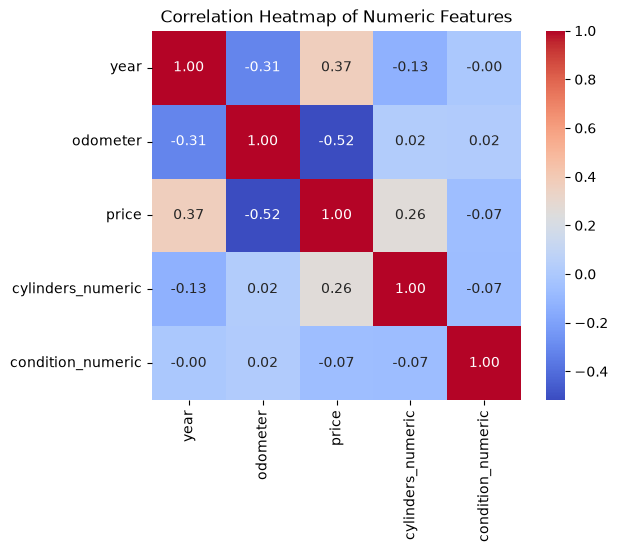

In [96]:
sns.heatmap(
    vehicles_simplified.corr(numeric_only=True),
    annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Simple Linear Regression Model

In [78]:
pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

pipe_linear

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [80]:
X = vehicles_simplified.drop(columns=['price'])
y = vehicles_simplified['price']

pipe_linear.fit(X, y)
mse = mean_squared_error(y, pipe_linear.predict(X))
mae = mean_absolute_error(y, pipe_linear.predict(X))
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Mean Squared Error: 106840373.64
Mean Absolute Error: 7537.31


In [128]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

RMSE: 10336.36


In [86]:
coefs = pd.DataFrame(
    pipe_linear.named_steps['linear'].coef_,
    index=X.columns,
    columns=['coef_']
).sort_values(by='coef_', key=abs, ascending=False)

coefs

,coef_
odometer,-5933.903492
cylinders_numeric,4036.118777
year,3579.886936
condition_numeric,-468.958695


In [90]:
vehicles_simplified['condition_numeric'].value_counts()

condition_numeric
2.0    263317
3.0     91819
4.0     19608
1.0      6216
5.0      1021
0.0       547
Name: count, dtype: int64

In [ ]:
# Drilling down into relationship between condition and price
vehicles_simplified.groupby('condition_numeric')['price'].mean()

condition_numeric
0.0     3822.241316
1.0     3834.435328
2.0    19828.755614
3.0    14856.771365
4.0    18006.022593
5.0    21424.864838
Name: price, dtype: float64

In [89]:
vehicles_simplified.groupby('condition_numeric')['price'].median()

condition_numeric
0.0     2000.0
1.0     2800.0
2.0    17888.0
3.0    11900.0
4.0    14500.0
5.0    17900.0
Name: price, dtype: float64

#### Findings
Based on the heatmap and the simple linear model applied onto the 4 numeric features:
1. Odometer has the biggest negative impact on price - higher odometer, lower price
2. Cylinder (converted to number) has a very high positive impact on price - higher cylinder count, typically means higher horsepower, leads to a higher price
3. Year has a very high positive impact on price - higher year in number, means newer cars, leads to a higher price
4. Surprisingly, condition (converted to number) has a low but negative impact on price in this model; however, overall price does have a increase trend when condition is better, condition 2.0 (good) has the highest volume of the data might mean this bucket is skewed, which introduced the negative coef in the model; overall, it's clear that the condition has a way lower impact than the other 3

### Polynomial Linear Regression Model

In [79]:
pipe_poly_linear = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

pipe_linear

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [97]:
model_finder_1 = GridSearchCV(pipe_poly_linear, \
            param_grid={'poly__degree': [1, 2, 3, 4, 5]}, \
            cv=5, \
            scoring='neg_mean_squared_error', \
            return_train_score=True)

model_finder_1.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``sc

In [98]:
model_finder_1.best_params_, model_finder_1.best_score_

({'poly__degree': 5}, np.float64(-88432989.47735472))

In [99]:
mf1_results = pd.DataFrame(model_finder_1.cv_results_)
print(mf1_results[['param_poly__degree', 'mean_train_score', 'mean_test_score']])

   param_poly__degree  mean_train_score  mean_test_score
0                   1     -1.067933e+08    -1.072661e+08
1                   2     -9.365348e+07    -9.437193e+07
2                   3     -8.825653e+07    -8.931588e+07
3                   4     -8.738598e+07    -8.878665e+07
4                   5     -8.658848e+07    -8.843299e+07


In [100]:
px.line(mf1_results, 
    x='param_poly__degree', 
    y=['mean_train_score', 'mean_test_score'], 
    title='Mean Train and Test Scores by Polynomial Degree', 
    labels={'value': 'Score', 'param_poly__degree': 'Polynomial Degree'}, 
    height=500, width=800)

#### Findings
Degree = 3 on PolynomialFeatures is ideal for ['odometer', 'year', 'cylinders_numeric', 'condition_numeric']

### Ridge Model with Sequential Feature Selector

In [103]:
from sklearn.compose import ColumnTransformer

poly_cols = ['odometer', 'year', 'cylinders_numeric', 'condition_numeric']

Xc = vehicles_cleaned.drop(columns=['price'])
yc = vehicles_cleaned['price']

preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=3, include_bias=False), poly_cols)
    ],
    remainder='passthrough'
)

pipe_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(
        Ridge(),
        n_features_to_select=15,
        direction='forward',
        scoring='neg_mean_squared_error',
        cv=5
    )),
    ('ridge', Ridge())
])

In [106]:
pipe_ridge.fit(Xc, yc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](83,)","['year','odometer','cylinders_numeric',...,'state_bucket_va', 'state_bucket_wa','state_bucket_wi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,83
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('poly', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [109]:
selector = pipe_ridge.named_steps['selector']
ridge = pipe_ridge.named_steps['ridge']

all_features = pipe_ridge.named_steps['preprocess'].get_feature_names_out()
selected_features = all_features[selector.get_support()]
coefs = ridge.coef_

best_15 = pd.DataFrame({
    'feature': selected_features,
    'coef': coefs
}).sort_values(by='coef', key=abs, ascending = False)

best_15

,feature,coef
4,poly__year^2 cylinders_numeric,128496.871963
2,poly__year cylinders_numeric,-124997.114087
1,poly__odometer cylinders_numeric,-6207.667666
6,remainder__fuel_gas,-4794.551806
0,poly__odometer,-2909.528331
8,remainder__fuel_other,-2829.395536
3,poly__odometer^3,2712.746374
9,remainder__drive_fwd,-2445.388092
12,remainder__type_pickup,1627.513317
7,remainder__fuel_hybrid,-1444.447113


In [111]:
mse_ridge = mean_squared_error(pipe_ridge.predict(Xc), yc)
mae_ridge = mean_absolute_error(pipe_ridge.predict(Xc), yc)

print(f"Mean Squared Error: {mse_ridge:.2f}")
print(f"Mean Absolute Error: {mae_ridge:.2f}")

Mean Squared Error: 79417080.64
Mean Absolute Error: 6211.60


In [129]:
rmse_ridge = np.sqrt(mse_ridge)
print(f"RMSE: {rmse_ridge:.2f}")

RMSE: 8911.63


#### Findings
1. Fuel type impacts the price: gas < (other <) hybrid < electric < diesel; gas cars tend to be cheaper and diesel cars are typically more expensive
2. FWD typically leads to a lower price
3. Pickup and truck tend to have higher price, while pickup tends to be more expensive than truck
4. Amount all manufacturers, Nissan stood out as a negative driver of the price

### Lasso Model

In [115]:
pipe_lasso = Pipeline([
    ('preprocess', preprocessor),
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

param = {'lasso__alpha': [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}
grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid = param, 
    cv = 5,
    scoring = 'neg_mean_squared_error'
)
grid_lasso.fit(Xc, yc)

print(f"Best alpha: {grid_lasso.best_params_['lasso__alpha']:.3f}")
print(f"Best CV RMSE: {np.sqrt(-grid_lasso.best_score_):.0f}")

/Users/effie.li/Documents/Berkeley/What_Drives_the_Price_of_a_Car/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.112951e+13, tolerance: 5.556e+09
  model = cd_fast.enet_coordinate_descent(
/Users/effie.li/Documents/Berkeley/What_Drives_the_Price_of_a_Car/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.087758e+13, tolerance: 5.534e+09
  model = cd_fast.enet_coordinate_descent(
/Users/effie.li/Documents/Berkeley/What_Drives_the_Price_of_a_Car/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objecti

Best alpha: 0.010
Best CV RMSE: 8624


/Users/effie.li/Documents/Berkeley/What_Drives_the_Price_of_a_Car/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.384216e+13, tolerance: 6.894e+09
  model = cd_fast.enet_coordinate_descent(


In [119]:
best_lasso = grid_lasso.best_estimator_.named_steps['lasso']
feature_names = grid_lasso.best_estimator_.named_steps['preprocess'].get_feature_names_out()

lasso_coefs = pd.DataFrame({
    'feature': feature_names,
    'coef': best_lasso.coef_
})

lasso_coefs[lasso_coefs['coef']!=0].sort_values(by='coef', key=abs, ascending=False)

,feature,coef
1,poly__year,-24556.663332
24,poly__year^3,16341.584137
8,poly__year^2,11251.083986
4,poly__odometer^2,-6801.790817
31,poly__cylinders_numeric^2 condition_numeric,6637.277170
...,...,...
53,remainder__type_missing,37.509604
93,remainder__state_bucket_ia,30.946037
52,remainder__type_mini-van,28.046686
68,remainder__paint_color_purple,11.544913


In [133]:
mse_lasso = -grid_lasso.best_score_
rmse_lasso = np.sqrt(mse_lasso)
print(f"RMSE: {rmse_lasso:.2f}")

RMSE: 8624.46


#### Findings
Lasso is struggling to drop feature, which suggests the model is overfitting; removing Polynomial to refit Ridge and Lasso

### Ridge without Polynomial

In [121]:
pipe_ridge_nopoly = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(
        Ridge(),
        n_features_to_select=15,
        direction='forward',
        scoring='neg_mean_squared_error',
        cv=5
    )),
    ('ridge', Ridge())
])

pipe_ridge_nopoly.fit(Xc, yc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](83,)","['year','odometer','cylinders_numeric',...,'state_bucket_va', 'state_bucket_wa','state_bucket_wi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,83
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [124]:
all_features_nopoly = pipe_ridge_nopoly.named_steps['scaler'].get_feature_names_out()
selected_features_nopoly = all_features_nopoly[pipe_ridge_nopoly.named_steps['selector'].get_support()]
coefs_nopoly = pipe_ridge_nopoly.named_steps['ridge'].coef_

best_15_nopoly = pd.DataFrame({
    'feature': selected_features_nopoly,
    'coef': coefs_nopoly
}).sort_values(by='coef', key=abs, ascending = False)

best_15_nopoly

,feature,coef
1,odometer,-6243.849490
4,fuel_gas,-4770.858901
0,year,3277.541370
6,fuel_other,-2714.515077
8,drive_fwd,-2245.731275
2,cylinders_numeric,1886.078705
11,type_pickup,1666.048592
5,fuel_hybrid,-1438.181611
9,drive_missing,-1232.800563
13,type_truck,1017.038306


In [134]:
mse_ridge_nopoly = mean_squared_error(pipe_ridge_nopoly.predict(Xc), yc)
mae_ridge_nopoly = mean_absolute_error(pipe_ridge_nopoly.predict(Xc), yc)
rmse_ridge_nopoly = np.sqrt(mse_ridge_nopoly)

print(f"Mean Squared Error: {mse_ridge_nopoly:.2f}")
print(f"Mean Absolute Error: {mae_ridge_nopoly:.2f}")
print(f"RMSE: {rmse_ridge_nopoly:.2f}")

Mean Squared Error: 81889642.05
Mean Absolute Error: 6453.25
RMSE: 9049.29


#### Findings
1. The noise from Poly = 3 is removed; feature impacts mostly align with previous findings
2. Sedan type of cars have lower prices
3. Title status "rebuilt" has a negative impact on price

### Lasso without Polymonial

In [135]:
pipe_lasso_nopoly = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

param = {'lasso__alpha': [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}
grid_lasso_nopoly = GridSearchCV(
    pipe_lasso_nopoly,
    param_grid = param, 
    cv = 5,
    scoring = 'neg_mean_squared_error'
)
grid_lasso_nopoly.fit(Xc, yc)

print(f"Best alpha: {grid_lasso_nopoly.best_params_['lasso__alpha']:.3f}")
print(f"Best CV RMSE: {np.sqrt(-grid_lasso_nopoly.best_score_):.0f}")

Best alpha: 0.010
Best CV RMSE: 8882


In [136]:
best_lasso_nopoly = grid_lasso_nopoly.best_estimator_.named_steps['lasso']
feature_names_nopoly = grid_lasso_nopoly.best_estimator_.named_steps['scaler'].get_feature_names_out()

lasso_coefs_nopoly = pd.DataFrame({
    'feature': feature_names_nopoly,
    'coef': best_lasso_nopoly.coef_
})

lasso_coefs_nopoly[lasso_coefs_nopoly['coef']!=0].sort_values(by='coef', key=abs, ascending=False)

,feature,coef
1,odometer,-6115.278823
5,fuel_gas,-4679.896563
0,year,3129.099107
7,fuel_other,-2789.933435
15,drive_fwd,-2360.816427
...,...,...
62,state_bucket_ga,26.504230
38,paint_color_purple,20.295896
59,state_bucket_ca,16.227936
63,state_bucket_ia,15.030870


In [137]:
mse_lasso_nopoly = -grid_lasso_nopoly.best_score_
rmse_lasso_nopoly = np.sqrt(mse_lasso_nopoly)
print(f"RMSE: {rmse_lasso_nopoly:.2f}")

RMSE: 8881.64


#### Findings
1. Best alpha is 0.01, still on the lower end, Lasso is not really punishing any feature; all features have fair impact on the model
2. Re-emphasizes some of the top features: odometer, gas, fwd negatively impact the price and year positively impact the price

[Back to Top](#top)

## 5. Evaluation <a id = 'evaluation'></a>

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Evaluation Metric: RMSE

We use **Root Mean Squared Error (RMSE)** as the primary metric.

- **Interpretable:** RMSE is in the target's units (dollars), so results read as "predictions are off by ~$X" — meaningful to a non-technical dealer audience.
- **Penalizes big misses:** it weights large errors more heavily than MAE, which fits the business (badly mispricing a car costs more than small misses).
- **Consistency:** `GridSearchCV` optimizes on negative MSE internally (monotonic with RMSE); we take the square root to report every model in dollars.

In [144]:
# Unified, apples-to-apples comparison: all models evaluated on the SAME hold-out test set.
# Earlier each model reported metrics differently (in-sample MSE/MAE vs CV RMSE); here we
# put every model on one 80/20 split and report Test RMSE, MAE and R2 in dollars.
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_full = vehicles_cleaned.drop(columns=['price'])   # all engineered/one-hot features
X_simp = vehicles_simplified.drop(columns=['price']) # 4 numeric features only
y_all  = vehicles_cleaned['price']

# One split, shared index -> both feature sets use the exact same train/test rows
idx_tr, idx_te = train_test_split(vehicles_cleaned.index, test_size=0.2, random_state=42)

def eval_model(pipe, X, name):
    pipe.fit(X.loc[idx_tr], y_all.loc[idx_tr])
    pred = pipe.predict(X.loc[idx_te])
    return {'Model': name,
            'Test RMSE': np.sqrt(mean_squared_error(y_all.loc[idx_te], pred)),
            'Test MAE' : mean_absolute_error(y_all.loc[idx_te], pred),
            'Test R2'  : r2_score(y_all.loc[idx_te], pred)}

# poly transformer on the 4 numeric drivers (rest passed through), matching earlier cells
pre_poly = ColumnTransformer(
    [('poly', PolynomialFeatures(degree=3, include_bias=False),
      ['odometer', 'year', 'cylinders_numeric', 'condition_numeric'])],
    remainder='passthrough')

# the 15 features chosen earlier by the no-poly Ridge SequentialFeatureSelector
sfs_features = list(selected_features_nopoly)

rows = []
# Baseline: always predict the mean training price
base = np.full(len(idx_te), y_all.loc[idx_tr].mean())
rows.append({'Model':'Baseline (predict mean price)',
             'Test RMSE': np.sqrt(mean_squared_error(y_all.loc[idx_te], base)),
             'Test MAE' : mean_absolute_error(y_all.loc[idx_te], base),
             'Test R2'  : r2_score(y_all.loc[idx_te], base)})
rows.append(eval_model(Pipeline([('scaler', StandardScaler()),
                                 ('linear', LinearRegression())]),
                       X_simp, 'Linear - 4 numeric features'))
rows.append(eval_model(Pipeline([('poly', PolynomialFeatures(degree=3, include_bias=False)),
                                 ('scaler', StandardScaler()),
                                 ('linear', LinearRegression())]),
                       X_simp, 'Polynomial deg-3 - 4 numeric features'))
rows.append(eval_model(Pipeline([('scaler', StandardScaler()),
                                 ('ridge', Ridge())]),
                       X_full[sfs_features], 'Ridge - 15 selected features (no poly)'))
rows.append(eval_model(Pipeline([('scaler', StandardScaler()),
                                 ('lasso', Lasso(alpha=0.01))]),
                       X_full, 'Lasso - all features (no poly)'))
rows.append(eval_model(Pipeline([('preprocess', pre_poly),
                                 ('scaler', StandardScaler()),
                                 ('lasso', Lasso(alpha=0.01))]),
                       X_full, 'Lasso - all features + poly deg-3'))

comparison = pd.DataFrame(rows).sort_values('Test RMSE').reset_index(drop=True)
comparison.round(2)

/Users/effie.li/Documents/Berkeley/What_Drives_the_Price_of_a_Car/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.109052e+13, tolerance: 5.523e+09
  model = cd_fast.enet_coordinate_descent(


,Model,Test RMSE,Test MAE,Test R2
0,Lasso - all features + poly deg-3,8484.31,5890.14,0.60
1,Lasso - all features (no poly),8746.39,6197.57,0.57
2,Ridge - 15 selected features (no poly),9008.15,6429.48,0.55
3,Polynomial deg-3 - 4 numeric features,9376.04,6534.76,0.51
4,Linear - 4 numeric features,10306.07,7526.68,0.41
5,Baseline (predict mean price),13385.30,11015.33,-0.00


In [145]:
# Visualize the comparison (lower RMSE = better)
fig = px.bar(comparison.sort_values('Test RMSE', ascending=False),
             x='Test RMSE', y='Model', orientation='h', text='Test RMSE',
             title='Model Comparison - Hold-out Test RMSE (lower is better)',
             labels={'Test RMSE': 'Test RMSE ($)'}, height=450, width=900)
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(margin=dict(l=10, r=60))
fig.show()

#### Findings

All models scored on the same 20% hold-out set, so metrics are directly comparable. RMSE/MAE are in dollars; R2 = share of price variance explained (baseline = 0).

- **Every model beats the baseline.** Numeric-only models reach R2 = 0.41-0.51; adding categorical features (fuel, drive, type, title, manufacturer) lifts R2 to 0.55-0.60 and cuts RMSE ~$1,300-1,800.
- **Best predictor wins only narrowly.** Poly deg-3 Lasso tops the table (RMSE ~$8,500, R2 = 0.60) but its strongest terms are uninterpretable, multicollinear interactions (e.g. `year^2 x cylinders`, ~+/-$128k). The interpretable no-poly models give up just ~3-6% RMSE for clean, sign-stable coefficients - the right trade for a client who needs reasons (prediction vs. inference).
- **Two methods agree on the drivers.** Ridge+SFS and Lasso, run separately, converge on the same signed list: odometer (strongest negative), year (strongest positive), fuel, FWD (neg), pickup/truck (premium), cylinders (pos), rebuilt title (neg), small Nissan discount. Agreement = strong cross-validation.
- **Good enough to advise, not to price one VIN.** ~40% of variance stays unexplained and typical error is ~$8,500 on a ~$15k median car - expected, since `model`/`region` were dropped and `size`/`condition`/`cylinders` were heavily missing.
- **Next iteration (optional):** biggest gains are in the Data phase - engineer `vehicle_age` and `miles_per_year`, recover `model` via target encoding, revisit `price = 0` placeholders.

[Back to Top](#top)

## 6. Deployment <a id = "deployment"></a>

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Report to the Dealership: What Drives Used Car Prices

**Bottom line:** ~60% of price variation is explained by a few attributes, and two independent models agree on the drivers.

**Raises value** (biggest first)

- Newer model year - largest positive driver
- Lower mileage
- Diesel fuel (gas is cheapest)
- Pickups & trucks (body-style premium)
- More cylinders (V6/V8)

**Lowers value** (biggest first)

- High odometer - largest negative driver
- Front-wheel drive (vs 4WD/RWD)
- Rebuilt title (vs clean)
- Sedans

**Two dominant levers:** mileage and model year outweigh everything else combined. Trim, drivetrain, and body style are secondary adjustments.

**Recommendations**

1. Price and acquire on **year + mileage first** - they drive most of the value.
2. Stock **trucks/pickups** for higher price points and margin; sedans for volume.
3. Prefer **clean titles**; only take rebuilt at a discounted buy price.
4. Use **diesel / larger-engine** units to anchor the high end; gas 4-cylinders for fast-turnover value tier.
5. Watch **drivetrain** by region - 4WD/RWD hold value better than FWD.

**Scope:** reliable for *directional* decisions (which segments to stock, how to tier the lot), **not** a per-VIN price calculator - typical error ~$8,500 on a ~$15k car. A follow-on phase adding vehicle model/trim would be needed for precise pricing.